<a href="https://colab.research.google.com/github/Mchawi-ke/Amazon-analysis/blob/main/Titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yasserh/titanic-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'titanic-dataset' dataset.
Path to dataset files: /kaggle/input/titanic-dataset


In [ ]:
import os
print(os.listdir(path))

['Titanic-Dataset.csv']


In [ ]:
#importing the dependencies
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split,cross_val_score,StratifiedKFold
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,recall_score,f1_score

In [ ]:
# Loading the data
df = pd.read_csv(f'{path}/Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


Data preprocessing


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.head(5)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [ ]:
# The No of the dataset rows "891" and columns "12"
df.shape

(891, 12)

Handling missing numbers

In [ ]:
# Checking missing values
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
df=df.drop(columns=['PassengerId','Name','Ticket','Cabin'])

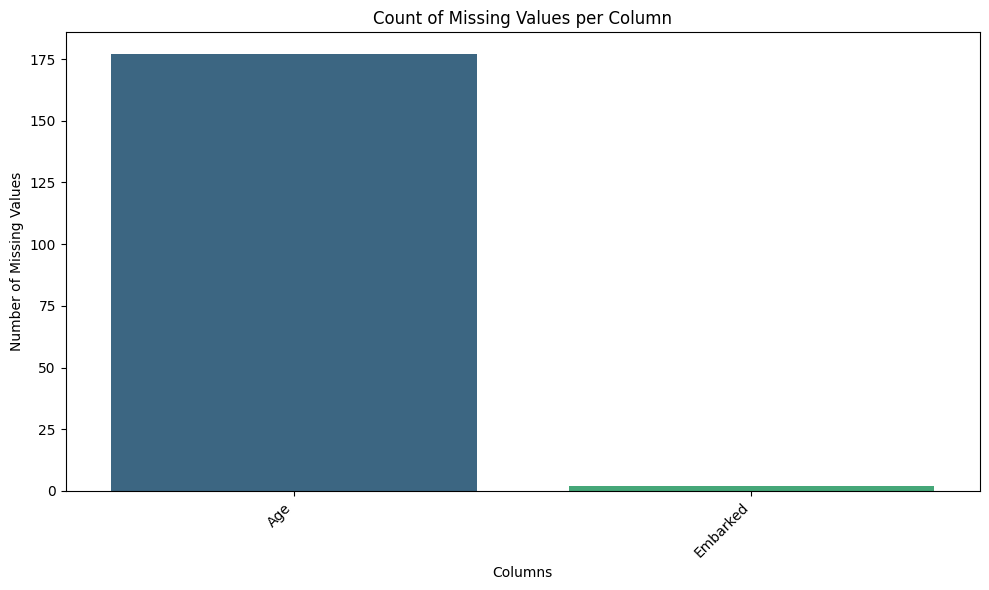

In [ ]:
# Calculate missing values
missing_data = df.isnull().sum()

# Filter out columns with no missing values for a clearer plot
missing_data = missing_data[missing_data > 0]

if not missing_data.empty:
    # Create a bar plot
    fig = plt.figure(figsize=(10, 6))
    sns.barplot(x=missing_data.index, y=missing_data.values, hue=missing_data.index, palette='viridis', legend=False)
    plt.title('Count of Missing Values per Column')
    plt.xlabel('Columns')
    plt.ylabel('Number of Missing Values')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('No missing values found in the DataFrame.')

In [ ]:
#replacing the missing values in age column with the mean values
mean_age = df['Age'].mean()
df['Age']=df['Age'].fillna(df['Age'].mean())

print(f"Missing 'Age' values imputed with the median: {mean_age}")r

Missing 'Age' values imputed with the median: 29.69911764705882


In [ ]:
#finding the mode value of Embarked column
df['Embarked'].mode()

,Embarked
0,S


In [ ]:
#replacing missing values in embarked column with the mode value-->most repeated value
mode_embarked = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(mode_embarked)

print(f"Missing 'Embarked' values imputed with the mode: {mode_embarked}")


Missing 'Embarked' values imputed with the mode: S


In [ ]:
# Verify that there are no more missing values in the entire DataFrame
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


Data Analysis

In [ ]:
#finding statistical measures about the data
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,13.002015,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,29.699118,0.000000,0.000000,14.454200
75%,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
#no.of people survied and died
# 0 - died, 1 - survived
df['Survived'].value_counts()

,count
Survived,
0,549
1,342


Data Visualization

In [ ]:
sns.set()

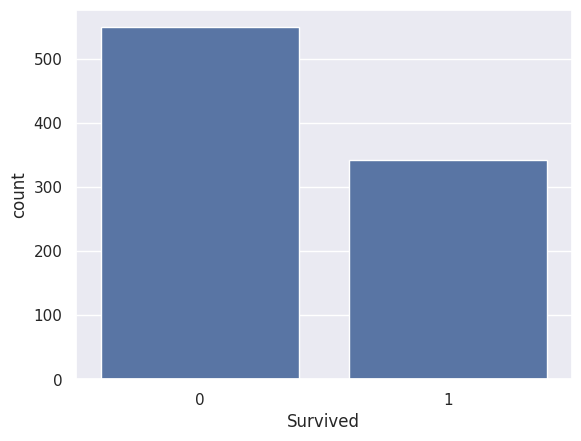

In [ ]:
#making a count plot for "Survived" column
sns.countplot(x='Survived',data=df)
plt.savefig('titanic-survival count.png',dpi=300,bbox_inches='tight')
plt.show()
plt.close()

,count
Sex,
male,577
female,314


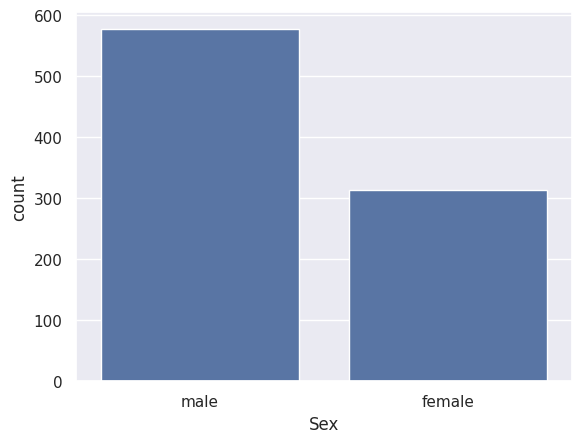

In [ ]:
#making countplot for no.of males and females travelled in the ship
sns.countplot(x='Sex',data=df)
df['Sex'].value_counts()

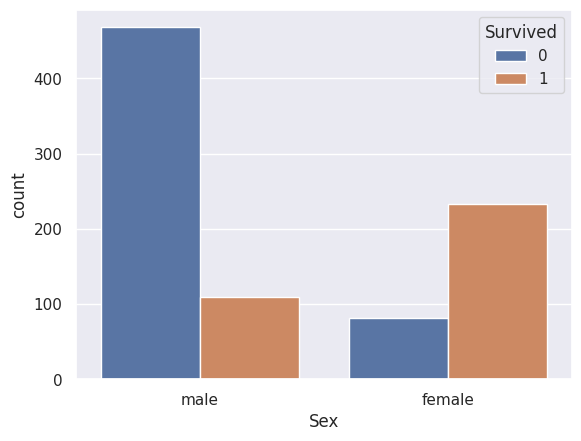

In [ ]:
#no.of survivors genderwise
sns.countplot(x='Sex',hue='Survived',data=df)
plt.savefig("survival_based_on_gender.png",dpi=300,bbox_inches='tight')
plt.show()
plt.close()

,count
Pclass,
3,491
1,216
2,184


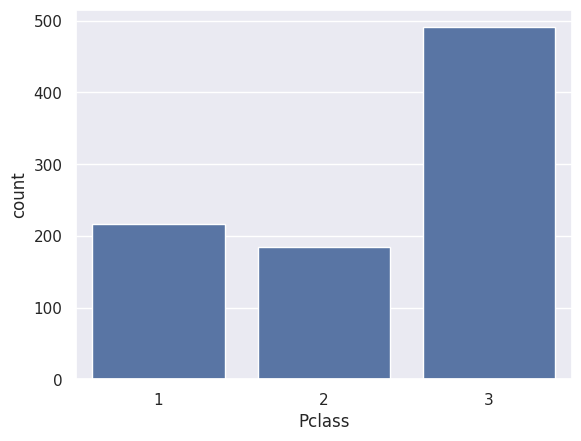

In [ ]:
#making countplot based on Pclass
sns.countplot(x='Pclass',data=df)
df['Pclass'].value_counts()

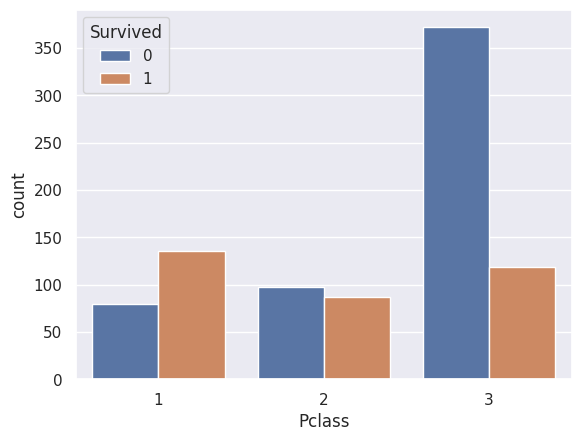

In [ ]:
#no.of surivors based on Pclass
sns.countplot(x='Pclass',hue='Survived',data=df)
plt.savefig("survival_based_on_class.png",dpi=300,bbox_inches='tight')
plt.show()
plt.close()


In [ ]:
df['Sex'].value_counts()

,count
Sex,
male,577
female,314


In [ ]:
df['Embarked'].value_counts()

,count
Embarked,
S,646
C,168
Q,77


In [ ]:
df.replace({'Sex':{'male':0,'female':1},'Embarked':{'S':0,'C':1,'Q':2}},inplace=True)

/tmp/ipykernel_4559/652182728.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'Sex':{'male':0,'female':1},'Embarked':{'S':0,'C':1,'Q':2}},inplace=True)


In [ ]:
x=df.drop(columns='Survived')
y=df['Survived']

In [ ]:
print(x)

     Pclass  Sex        Age  SibSp  Parch     Fare  Embarked
0         3    0  22.000000      1      0   7.2500         0
1         1    1  38.000000      1      0  71.2833         1
2         3    1  26.000000      0      0   7.9250         0
3         1    1  35.000000      1      0  53.1000         0
4         3    0  35.000000      0      0   8.0500         0
..      ...  ...        ...    ...    ...      ...       ...
886       2    0  27.000000      0      0  13.0000         0
887       1    1  19.000000      0      0  30.0000         0
888       3    1  29.699118      1      2  23.4500         0
889       1    0  26.000000      0      0  30.0000         1
890       3    0  32.000000      0      0   7.7500         2

[891 rows x 7 columns]


In [ ]:
print(y)


0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64


Splittng data into training and testint data

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=4,test_size=0.2)

In [ ]:
print(x.shape,x_train.shape,x_test.shape)

(891, 7) (712, 7) (179, 7)


Data Standardization

In [ ]:
scaler=StandardScaler()

In [ ]:
x_train_scaled=scaler.fit_transform(x_train)

In [ ]:
x_test_scaled=scaler.transform(x_test)

Model training

In [ ]:
model=LogisticRegression()

In [ ]:
classifier=model.fit(x_train_scaled,y_train)

In [ ]:
y_train_pred=model.predict(x_train_scaled)
y_test_pred=model.predict(x_test_scaled)

Model evaluation

Confusion Matrix

In [ ]:
cm=confusion_matrix(y_test,y_test_pred)
print(cm)

[[108  11]
 [ 20  40]]


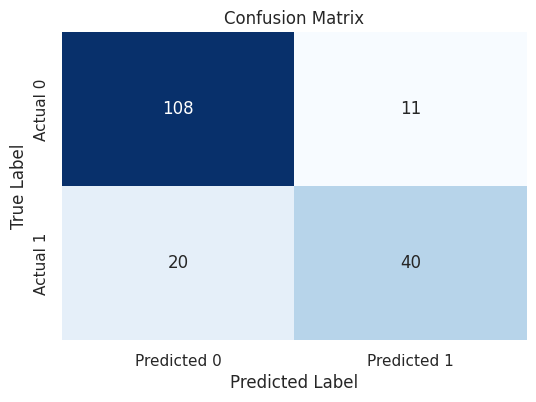

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',cbar=False,
            xticklabels=['Predicted 0','Predicted 1'],
            yticklabels=['Actual 0','Actual 1'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.savefig("Confusion-matrix.png",dpi=300,bbox_inches='tight')

In [ ]:
training_accuracy=accuracy_score(y_train,y_train_pred)
print("Accuracy score of training data prediction: ",training_accuracy)

Accuracy score of training data prediction:  0.7935393258426966


In [ ]:
#accuracy score for testing data
testing_accuracy=accuracy_score(y_test,y_test_pred)
print("Accuracy score: ",testing_accuracy)

Accuracy score:  0.8268156424581006


In [ ]:
#precion score
precision=precision_score(y_test,y_test_pred)
print("Precision score: ",precision)

Precision score:  0.7843137254901961


In [ ]:
#recall score
recall=recall_score(y_test,y_test_pred)
print("Recall score: ",recall)

Recall score:  0.6666666666666666


In [ ]:
#f1 score
f1=f1_score(y_test,y_test_pred)
print("f1 score: ",f1)

f1 score:  0.7207207207207207


In [ ]:
#using pipline prevents data leakage
pipeline=Pipeline([('scaler',StandardScaler()),('model',LogisticRegression())])
cv_strategy=StratifiedKFold(n_splits=10,shuffle=True,random_state=42)
cv_score=cross_val_score(pipeline,x,y,cv=cv_strategy,scoring='accuracy')
print("Cross Validation Scores: ",cv_score)
print("Mean Accuracy: ",cv_score.mean().round(4))
print("Standard Deviation: ",cv_score.std().round(4))

Cross Validation Scores:  [0.84444444 0.75280899 0.76404494 0.82022472 0.76404494 0.80898876
 0.76404494 0.82022472 0.84269663 0.78651685]
Mean Accuracy:  0.7968
Standard Deviation:  0.033
